<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Deep Generative Models
</font>

<hr/>
<font color="#800080" size=5>
Assignment 2: Variational Autoencoders
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2024
<br>
</font>
<font face="Times New Roman" size=4>
Deadline: Month day at 23:55
</font>
<hr>
</div></font>

In [1]:
import numpy as np
from tqdm import trange
from matplotlib import pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

In [2]:
# Get cpu, gpu or mps device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Dataset (5 points)

Download the MNIST dataset and merge the train and test datasets for training the generative model.

In [3]:
# TODO: Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load train and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.05MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]


Merge the two datasets to train the model on the images.

In [4]:
# TODO: Concatenate train and test datasets
merged_dataset = ConcatDataset([train_dataset, test_dataset])
merged_loader = DataLoader(merged_dataset, batch_size=64, shuffle=True)

print(f'The size of the merged dataset is {len(merged_loader.dataset)}')

The size of the merged dataset is 70000


# EDA (10 points)

Plot the distribution of each class in the dataset.

In [7]:
def plot_class_distribution(dataloader):
    # TODO: Initialize a dictionary to count occurrences of each class
    class_counts = {i: 0 for i in range(10)}  # MNIST has 10 classes: 0–9

    # TODO: Iterate through the DataLoader to count the labels
    for _, labels in dataloader:
        labels = labels.tolist()
        for label in labels:
            class_counts[label] += 1

    # TODO: Plot the histogram
    plt.figure(figsize=(10, 8))
    plt.bar(class_counts.keys(), class_counts.values(),color='crimson')
    plt.xlabel("Class")
    plt.ylabel("Frequency")
    plt.title("Class Distribution")
    plt.xticks(range(10))
    plt.show()



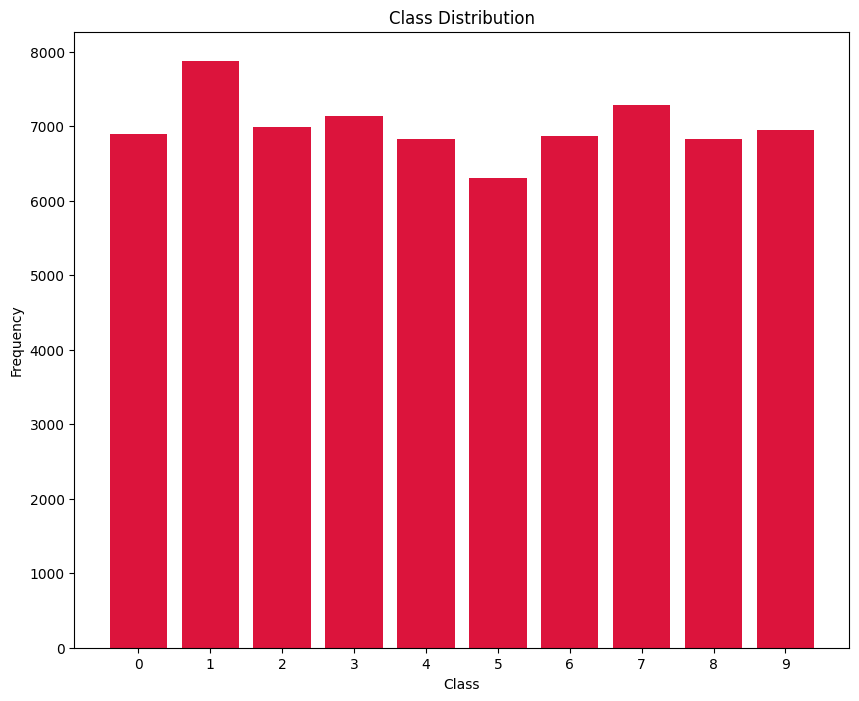

In [8]:
plot_class_distribution(merged_loader)

Plot the average of each class in the dataset.

In [9]:
def plot_class_averages(dataloader):
    # Initialize accumulators
    sums = {i: torch.zeros((28, 28)) for i in range(10)}   # MNIST images are 28x28
    counts = {i: 0 for i in range(10)}

    # Iterate over the DataLoader
    for images, labels in dataloader:
        # Ensure images are shape [batch, 1, 28, 28]
        if images.ndim == 4:
            images = images.squeeze(1)  # remove channel dim -> [batch, 28, 28]

        for img, label in zip(images, labels):
            sums[label.item()] += img
            counts[label.item()] += 1

    # Calculate average images
    averages = {cls: sums[cls] / counts[cls] for cls in sums.keys()}

    # Plot the averages
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    axes = axes.flatten()
    for cls, ax in zip(range(10), axes):
        ax.imshow(averages[cls], cmap="gray")
        ax.set_title(f"Class {cls}")
        ax.axis("off")

    plt.suptitle("Average Images per Class")
    plt.tight_layout()
    plt.show()


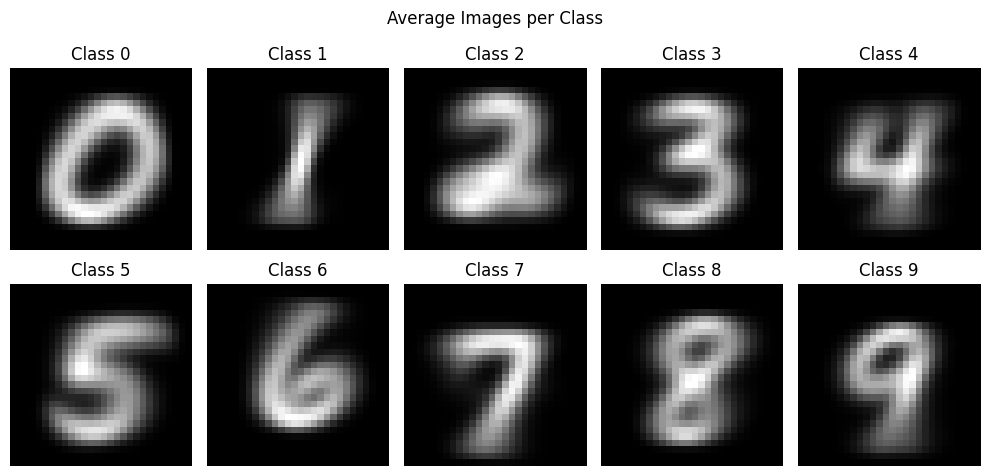

In [10]:
plot_class_averages(merged_loader)

# Variational Autoencoder (25 points)

In [5]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc_mean = nn.Linear(256, latent_dim)  # mean of latent space
        self.fc_logvar = nn.Linear(256, latent_dim)  # log-variance of latent space

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 256)
        self.fc4 = nn.Linear(256, 512)
        self.fc5 = nn.Linear(512, 28*28)

        # Add batch normalization for better training stability
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(256)
        self.bn4 = nn.BatchNorm1d(512)

        # Add dropout for regularization
        self.dropout = nn.Dropout(0.2)

    def encode(self, x):
        x = x.view(x.size(0), -1)  # flatten
        h = F.relu(self.bn1(self.fc1(x)))
        h = self.dropout(h)
        h = F.relu(self.bn2(self.fc2(h)))
        h = self.dropout(h)
        mean = self.fc_mean(h)
        logvar = self.fc_logvar(h)
        
        # Add temperature scaling for better latent space organization
        logvar = torch.clamp(logvar, min=-10, max=10)  # Prevent extreme values
        
        return mean, logvar

    def reparameterization(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def decode(self, z):
        # Add a small amount of noise to prevent posterior collapse
        z = z + 0.01 * torch.randn_like(z)
        
        h = F.relu(self.bn3(self.fc3(z)))
        h = self.dropout(h)
        h = F.relu(self.bn4(self.fc4(h)))
        h = self.dropout(h)
        x_recon = torch.sigmoid(self.fc5(h))
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_recon = self.decode(z)
        return x_recon, mean, logvar

    # Additional method for latent space sampling
    def sample(self, num_samples, device):
        """Generate samples from the latent space"""
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples

    # Additional method for getting latent representations
    def get_latent(self, x):
        """Get latent representation without reparameterization"""
        with torch.no_grad():
            mean, logvar = self.encode(x)
            return mean

In [6]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []

# Training (20 points)

Define the loss function for training the VAE. The loss functions should be a combination of the reconstruction loss and the KL-divergence loss. You can choose to increase the weight of these losses to achieve better results.

In [7]:
def loss_function(x, x_hat, mean, log_var, recon_weight=1.0, kl_weight=0.01):
    """
    VAE loss = reconstruction loss + KL divergence

    Args:
        x: original images (batch_size, 1, 28, 28)
        x_hat: reconstructed images (batch_size, 1, 28, 28)
        mean: latent mean (batch_size, latent_dim)
        log_var: latent log-variance (batch_size, latent_dim)
        recon_weight: weight for reconstruction loss
        kl_weight: weight for KL divergence loss

    Returns:
        total_loss: combined loss
        recon_loss: reconstruction loss only
        kl_loss: KL divergence loss only
    """
    # Flatten images for reconstruction loss
    x = x.view(x.size(0), -1)
    x_hat = x_hat.view(x_hat.size(0), -1)

    # Reconstruction loss (binary cross-entropy)
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp()) / x.size(0)

    # Weighted total loss
    total_loss = recon_weight * recon_loss + kl_weight * kl_loss

    return total_loss, recon_loss, kl_loss


Now you must train your network using the loss function you defined earlier. Make sure to plot and monitor the training loss over epochs.

In [8]:
from tqdm import tqdm

def plot_losses(losses):
    """
    Plot training losses over epochs.
    
    Args:
        losses: Dictionary containing loss arrays
    """
    plt.figure(figsize=(12, 4))
    
    # Plot total loss
    plt.subplot(1, 3, 1)
    plt.plot(losses['total'], label='Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Total Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot reconstruction loss
    plt.subplot(1, 3, 2)
    plt.plot(losses['recon'], label='Reconstruction Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Reconstruction Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot KL divergence loss
    plt.subplot(1, 3, 3)
    plt.plot(losses['kl'], label='KL Divergence Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('KL Divergence Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
def train(model, optimizer=optimizer, merged_loader=merged_loader, device=device, n_epochs=50):
    """
    Training loop for the VAE.
    """
    model.to(device)
    model.train()

    # Store losses
    losses = {'total': [], 'recon': [], 'kl': []}
    for epoch in tqdm(range(1, n_epochs + 1), desc=f'training ... '):
        total_loss_epoch = 0
        recon_loss_epoch = 0
        kl_loss_epoch = 0

        for batch_idx, (x, _) in enumerate(merged_loader):
            x = x.to(device)

            optimizer.zero_grad()
            x_hat, mean, log_var = model(x)
            loss, recon_loss, kl_loss = loss_function(x, x_hat, mean, log_var)

            loss.backward()
            optimizer.step()

            total_loss_epoch += loss.item()
            recon_loss_epoch += recon_loss.item()
            kl_loss_epoch += kl_loss.item()

            

        # Average losses per epoch
        total_loss_epoch /= len(merged_loader)
        recon_loss_epoch /= len(merged_loader)
        kl_loss_epoch /= len(merged_loader)
        # print('total_loss_epoch = ', total_loss_epoch)

        losses['total'].append(total_loss_epoch)
        losses['recon'].append(recon_loss_epoch)
        losses['kl'].append(kl_loss_epoch)

    
    return losses


In [9]:
losses = train(model, optimizer)

training ... : 100%|██████████| 50/50 [08:50<00:00, 10.61s/it]


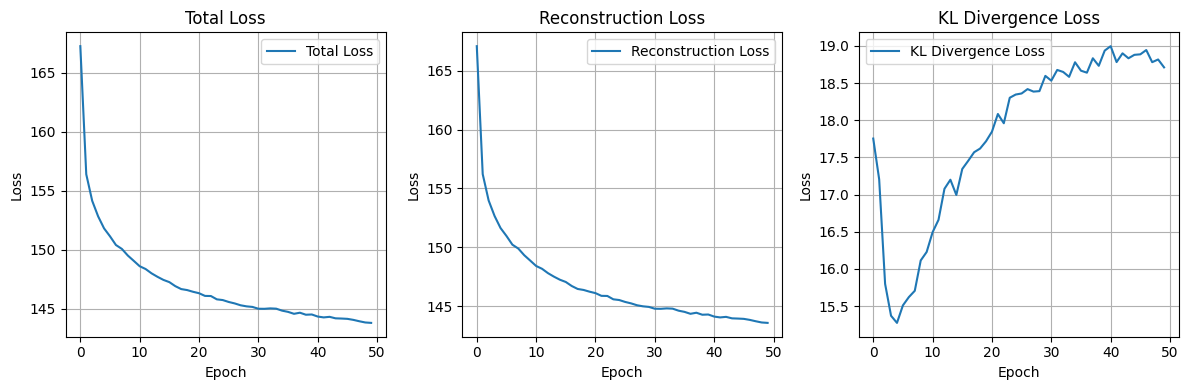

In [10]:
plot_losses(losses)

# The Encoder (20 points)

Let's first take a look at the encoder. Start by visualizing the latent dimension for the merged dataset.

In [11]:
def visualize(vae, dataloader, batch_count=30, title='Latent Space Visualization'):
    """
    Visualize the latent space of a VAE.
    
    Args:
        vae: trained VAE model
        dataloader: DataLoader for dataset
        batch_count: number of batches to use for visualization
        title: plot title
    """
    vae.eval()
    device = next(vae.parameters()).device

    all_means = []
    all_labels = []

    with torch.no_grad():
        for i, (x, y) in enumerate(dataloader):
            if i >= batch_count:
                break
            x = x.to(device)
            mean, _ = vae.encode(x)  # only need mean for visualization
            all_means.append(mean.cpu())
            all_labels.append(y)

    # Concatenate all batches
    all_means = torch.cat(all_means, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    # Only works if latent_dim == 2
    if all_means.shape[1] != 2:
        raise ValueError("Latent dimension must be 2 for 2D visualization.")

    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(all_means[:, 0], all_means[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.title(title)
    plt.show()


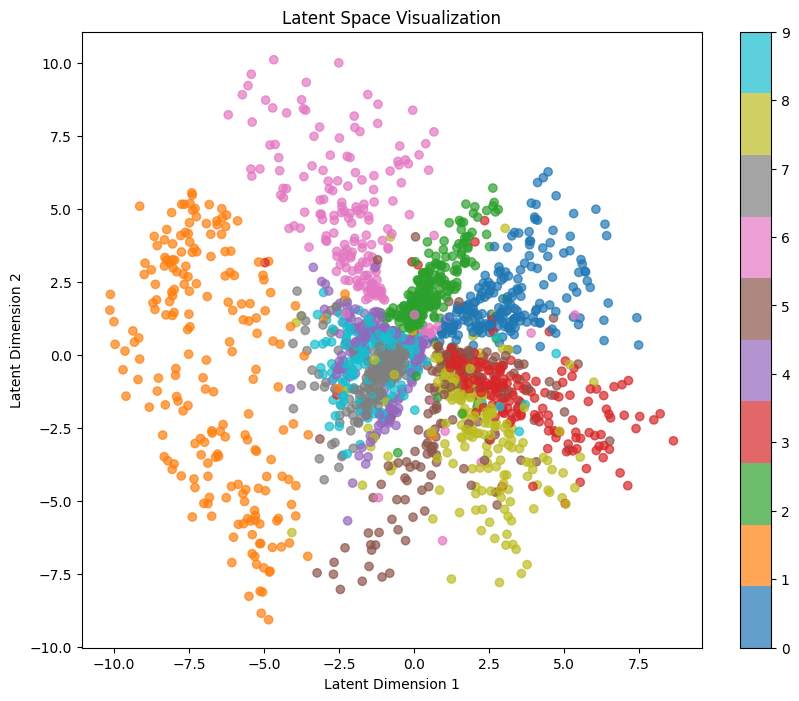

In [12]:
visualize(model, merged_loader)

Imagine if the input data for the encoder followed a very different distribution. Invert the images in the original datset and plot the latent dimension once more to show the difference.

In [13]:
def inverted_visualize(vae, dataloader, batch_count=30, title='Inverted Latent Space Visualization'):
    """
    Visualize the latent space of a VAE for inverted images.

    Args:
        vae: trained VAE model
        dataloader: DataLoader for dataset
        batch_count: number of batches to use for visualization
        title: plot title
    """
    vae.eval()
    device = next(vae.parameters()).device

    all_means = []
    all_labels = []

    with torch.no_grad():
        for i, (x, y) in enumerate(dataloader):
            if i >= batch_count:
                break
            # Invert images: 1 - x (since MNIST pixels are in [0,1])
            x_inverted = 1.0 - x.to(device)
            mean, _ = vae.encode(x_inverted)  # get latent mean
            all_means.append(mean.cpu())
            all_labels.append(y)

    # Concatenate all batches
    all_means = torch.cat(all_means, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    # Only works if latent_dim == 2
    if all_means.shape[1] != 2:
        raise ValueError("Latent dimension must be 2 for 2D visualization.")

    # Plot
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(all_means[:, 0], all_means[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.title(title)
    plt.show()


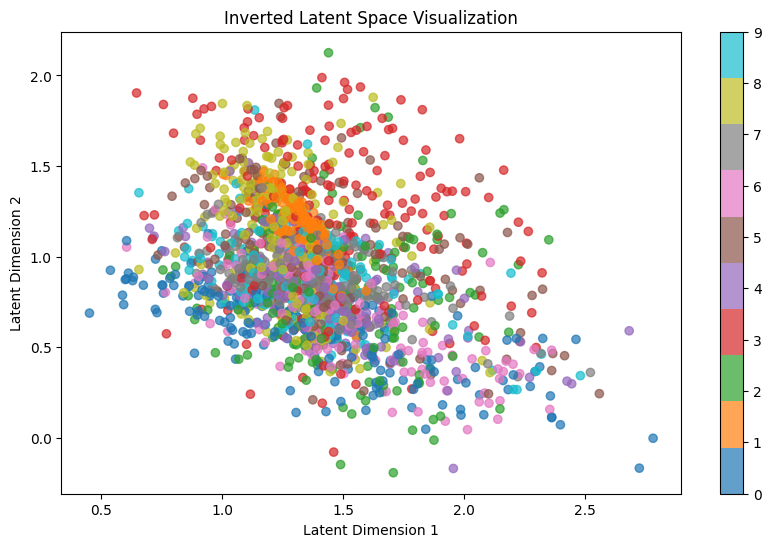

In [14]:
inverted_visualize(model, merged_loader)

Explain how the difference in the latent dimension allows us to detect data samples that don't follow the original distribution. How can this difference be used for anomaly detection? If we had used an autoencoder instead, what would be our observation then?


In a **Variational Autoencoder (VAE)**:

- The encoder maps an input \(x\) to a **distribution** in latent space, defined by a mean \(\mu\) and variance \(\sigma^2\).  
- The VAE is trained to **regularize the latent space** towards a prior distribution, usually a standard normal \(N(0,1)\), using the KL-divergence term.

**Consequences:**

1. The latent space becomes **compact and continuous**, with most training samples clustered in high-density regions.  
2. **Out-of-distribution (OOD) samples** are likely to be mapped to **low-density regions** far from the main cluster.  
3. The latent space can therefore be used to detect anomalies by measuring **distance from the cluster center** or evaluating the KL divergence.

**How this helps anomaly detection:**

- Compute the latent mean \(\mu\) for a new sample.  
- Measure its distance from the main latent cluster (e.g., Euclidean or Mahalanobis distance).  
- Large deviations indicate potential anomalies.  
- Reconstruction error can also be used as an additional anomaly signal.

---

### Latent Space in a Standard Autoencoder

For a **regular autoencoder**:

- The latent space is **deterministic and unstructured**.  
- Points far from the training clusters do not have predictable locations.  
- **Observation:** OOD samples may still reconstruct poorly, but the latent space alone is **not reliable for detecting anomalies**.  

Thus, anomaly detection in standard autoencoders usually relies solely on **reconstruction error**.

---


| Aspect                    | VAE                                   | Autoencoder (AE)                     |
|----------------------------|---------------------------------------|-------------------------------------|
| Latent space structure     | Probabilistic, regularized to N(0,1) | Deterministic, unstructured        |
| Anomaly detection          | Latent deviation + reconstruction     | Only reconstruction error           |
| Out-of-distribution points | Latent means fall in low-density zones| Harder to detect in latent space    |
| Benefit of KL regularization | Smooth latent manifold for generation | No smooth manifold guarantee        |



# The Decoder (20 points)

In this section we are going to test the properties of the decoder. First implement a function to create samples based on the input mean and variance.

In [15]:
def generate_digit(model, mean, var):
    """
    Generate a digit from given latent mean and variance using the VAE decoder.
    """
    device = next(model.parameters()).device
    # Sample using reparameterization trick
    z = model.reparameterization(mean.to(device), var.to(device))
    x_hat = model.decode(z)
    return x_hat.squeeze().detach().cpu()  # detach before converting to numpy


Now using this function plot the decoded output sampled from a uniform distribution from -1 to +1.

In [16]:
def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # TODO: Display a n*n 2D manifold of digits and construct a grid
    figure = np.zeros((digit_size*n, digit_size*n))
    x_grid = np.linspace(-scale, scale, n)
    y_grid = np.linspace(-scale, scale, n)[::-1]

    # TODO: Generate images for the grid
    for y_counter, yi in enumerate(y_grid):
        for x_counter, xi in enumerate(x_grid):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            digit = model.decode(z_sample)[0].detach().cpu().reshape(digit_size, digit_size)
            figure[y_counter * digit_size : (y_counter + 1) * digit_size, x_counter * digit_size : (x_counter + 1) * digit_size,] = digit

    # TODO: Display the results
    plt.figure(figsize=(figsize, figsize))
    x_range = digit_size // 2
    y_range = n * digit_size + digit_size//2
    range_pixels = np.arange(x_range, y_range, digit_size)
    x_range = np.round(x_grid, 1)
    y_range = np.round(y_grid, 1)
    plt.xticks(range_pixels, x_range)
    plt.yticks(range_pixels, y_range)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.title('VAE Latent Space Visualization')
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

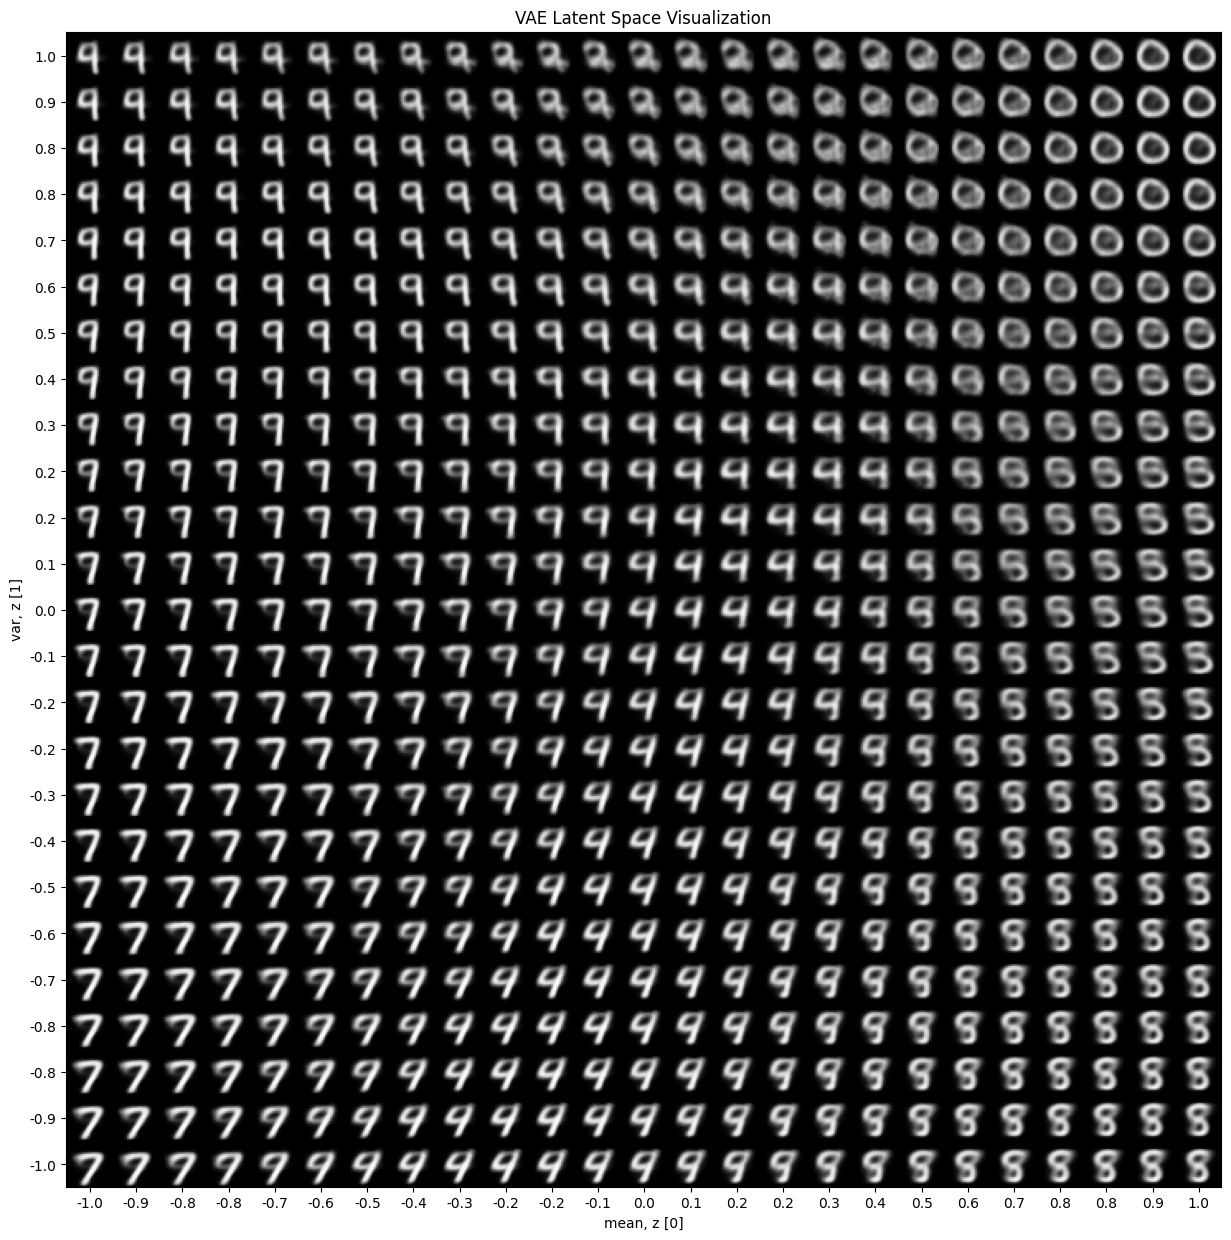

In [17]:
plot_latent_space(model)

What happens when you sample from regions outside the aformentioned space? Why? What could we expect if the network was not a variational autoencoder, but a simple autoencoder instead?


When sampling from regions outside the trained latent space, the decoder may produce unrealistic or nonsensical outputs, as it has not learned to represent those areas. The network extrapolates poorly, leading to artifacts or out-of-distribution samples.

In other words, the regions of trained latent space, are the regions the decoder is modeling the probility of x given z perfectly leading to qualified generated images. While in regions outside there, the optimization and training is not done perfectly and the probability of x given z is not optimized well.

If using a simple autoencoder instead, the output would likely still be nonsensical, but without the probabilistic nature of a VAE, it wouldn't provide uncertainty estimates. Thus, it would be even harder to identify anomalies or meaningful patterns in the output.

Having z space (latent space) and modeling its probabilities helps us to understand what is normal and what is abnormal. But we miss this in autoencoders.
